# 연간 vs 월간 4중 분해 — 재현 노트북

논문 `paper.md`의 모든 표(1–5)·그림(1–3)을 KCSDB2에서 재계산한다.
fm_fourway·fm_gap_groups 두 그림은 표 2·표 4와의 중복으로 논문에서 제외되었으나 참고용으로 계속 생성한다.
동일 원자료·동일 항등식을 두 빈도(연간 Δ₁ / 월간 Δ₁₂)에 적용하는 것이 방법의 전부다.

**편차**: 기간 2026.03까지(월간 231개월·연간 2007–2025) · 수량=중량(kg) · HS 개정 원코드+개정연도 제외 강건성 · 조업일수/명절 조정 미실행. 실행 시간 약 2–4분.

In [1]:
import os, duckdb
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.width', 240); pd.set_option('display.unicode.east_asian_width', True)

# ---- 논문용 그림 스타일: 한글(맑은고딕) · 흑백 · 500dpi ----
plt.rcParams.update({
    'font.family': 'Malgun Gothic', 'axes.unicode_minus': False,
    'font.size': 10, 'axes.titlesize': 11.5, 'axes.labelsize': 10.5,
    'xtick.labelsize': 9.5, 'ytick.labelsize': 9.5, 'legend.fontsize': 9.5,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 0.8, 'axes.grid': True, 'grid.color': '0.87', 'grid.linewidth': 0.6,
    'legend.frameon': False, 'savefig.dpi': 500,
})
MGRAY='0.55'
def save_show(f, name):
    f.tight_layout()
    f.savefig(os.path.join(IMG, name), bbox_inches='tight')
    f.savefig(os.path.join(IMG, os.path.splitext(name)[0]+'.pdf'), bbox_inches='tight')
    plt.show()

ROOT = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(ROOT, "data", "processed", "kcsdb.duckdb")):
    up = os.path.dirname(ROOT)
    if up == ROOT:
        raise FileNotFoundError("KCSDB2 루트를 찾지 못했습니다")
    ROOT = up
DB = os.path.join(ROOT, "data", "processed", "kcsdb.duckdb")
IMG = os.path.join(ROOT, 'analysis', '한국 수출입 4중분해', 'img'); os.makedirs(IMG, exist_ok=True)
con = duckdb.connect(); con.execute(f"ATTACH '{DB}' AS src (READ_ONLY)")
def q(s): return con.sql(s).df()

# 셀 패널: 수출/수입 × 월간/연간
con.execute('''CREATE TEMP TABLE mx AS
SELECT yyyymm, stat_cd, SUBSTR(hs10,1,6) hs6, SUM(exp_dlr)::DOUBLE v, SUM(exp_wgt)::DOUBLE w
FROM src.fact_trade WHERE exp_dlr>0 GROUP BY 1,2,3''')
con.execute('''CREATE TEMP TABLE mm AS
SELECT yyyymm, stat_cd, SUBSTR(hs10,1,6) hs6, SUM(imp_dlr)::DOUBLE v, SUM(imp_wgt)::DOUBLE w
FROM src.fact_trade WHERE imp_dlr>0 GROUP BY 1,2,3''')
con.execute("CREATE TEMP TABLE ax AS SELECT yyyymm//100 yr, stat_cd, hs6, SUM(v) v, SUM(w) w FROM mx WHERE yyyymm//100<=2025 GROUP BY 1,2,3")
con.execute("CREATE TEMP TABLE am AS SELECT yyyymm//100 yr, stat_cd, hs6, SUM(v) v, SUM(w) w FROM mm WHERE yyyymm//100<=2025 GROUP BY 1,2,3")
for t in ['mx','mm','ax','am']: print(t, con.sql(f"SELECT COUNT(*) FROM {t}").fetchone()[0])
print('고유 수출 셀 조합:', con.sql("SELECT COUNT(*) FROM (SELECT DISTINCT stat_cd, hs6 FROM mx)").fetchone()[0])

GROUPS = [
 ('반도체(8541·42)', "SUBSTR(hs6,1,4) IN ('8541','8542')"),
 ('에너지(27)',      "SUBSTR(hs6,1,2)='27'"),
 ('자동차(87)',      "SUBSTR(hs6,1,2)='87'"),
 ('기계(84)',        "SUBSTR(hs6,1,2)='84'"),
 ('화학(28·29·39)',  "SUBSTR(hs6,1,2) IN ('28','29','39')"),
 ('기타',            "SUBSTR(hs6,1,4) NOT IN ('8541','8542') AND SUBSTR(hs6,1,2) NOT IN ('27','87','84','28','29','39')"),
]

mx 13924306
mm 11036091
ax 2595138
am 1891324
고유 수출 셀 조합: 357384


## 표 1. 품목군 수출입 비중 (연간) · §2.1 각주용 8541/8542 비중

In [2]:
def shares(tab):
    tot=q(f"SELECT yr, SUM(v) s FROM {tab} GROUP BY 1").set_index('yr')['s']
    out=pd.DataFrame(index=tot.index)
    for nm,cond in GROUPS[:-1]:
        g=q(f"SELECT yr, SUM(v) s FROM {tab} WHERE {cond} GROUP BY 1").set_index('yr')['s']
        out[nm]=(g/tot*100)
    return out.round(1)
shx, shm = shares('ax'), shares('am')
yrs=[2007,2010,2013,2016,2019,2022,2025]
print("[수출]"); print(shx.loc[yrs].to_string())
print("[수입]"); print(shm.loc[yrs].to_string())

# §2.1 각주: 반도체 품목군 내 8541(개별소자) 대 8542(집적회로) 수출액 비중
d41=q("SELECT SUBSTR(hs6,1,4) hs4, SUM(v) v FROM mx WHERE SUBSTR(hs6,1,4) IN ('8541','8542') GROUP BY 1")
d25=q("SELECT SUBSTR(hs6,1,4) hs4, SUM(v) v FROM mx WHERE SUBSTR(hs6,1,4) IN ('8541','8542') AND yyyymm//100=2025 GROUP BY 1")
for nm,dd in [('전기간(2007.01-2026.03)',d41),('2025년',d25)]:
    t=dd['v'].sum()
    s={r['hs4']: r['v']/t*100 for _,r in dd.iterrows()}
    print(f"[각주] {nm}: HS8541 {s['8541']:.1f}% / HS8542 {s['8542']:.1f}%")

[수출]
      반도체(8541·42)  에너지(27)  자동차(87)  기계(84)  화학(28·29·39)
yr                                                                     
2007              8.6         6.6        13.2      11.7             9.2
2010              9.2         7.0        11.5      11.2             9.4
2013              9.4         9.7        13.0      10.6            10.6
2016             11.7         5.5        12.6      11.8             9.9
2019             15.6         7.8        11.6      13.1            10.8
2022             17.2         9.5        11.1      10.7            11.9
2025             20.7         6.7        13.0      12.0             8.7
[수입]
      반도체(8541·42)  에너지(27)  자동차(87)  기계(84)  화학(28·29·39)
yr                                                                     
2007              7.9        27.0         1.9      10.9             5.8
2010              6.7        28.8         1.9      11.2             6.3
2013              6.4        35.0         2.0       9.2             6.0
2016    

## 분해 함수 (층위 1·2, 4중 통합) — `maxm`은 월간 표본 절단 강건성용

In [3]:
def level1(tab, freq, cond="1=1", maxm=None):
    per,lag = ('yyyymm',100) if freq=='M' else ('yr',1)
    cut = f"AND yyyymm<={maxm}" if (maxm and freq=='M') else ""
    d=q(f"SELECT {per} p, SUM(v) X, COUNT(*) N FROM {tab} WHERE {cond} {cut} GROUP BY 1 ORDER BY 1")
    d=d.merge(d[['p','X','N']].rename(columns={'p':'pl','X':'X0','N':'N0'}), left_on=d['p']-lag, right_on='pl', how='left')
    d['g']=np.log(d['X']/d['X0']); d['dN']=np.log(d['N']/d['N0']); d['dB']=d['g']-d['dN']
    v=d.dropna(subset=['g']); V=v['g'].var(ddof=1)
    return v[['p','g','dN','dB']], dict(T=len(v),Vg=V,ext=v['dN'].var(ddof=1)/V,int_=v['dB'].var(ddof=1)/V,cov=2*v['dN'].cov(v['dB'])/V)

def level2(tab, freq, cond="1=1", lim=50, maxm=None):
    per,lag = ('yyyymm',100) if freq=='M' else ('yr',1)
    trim = f"AND ABS(LN((a.v/a.w)/(b.v/b.w)))<=LN({lim}) AND ABS(LN(a.w/b.w))<=LN({lim})" if lim else ""
    cut = f"AND a.yyyymm<={maxm}" if (maxm and freq=='M') else ""
    d=q(f'''WITH pr AS (SELECT a.{per} p, LN((a.v/a.w)/(b.v/b.w)) dlnp, LN(a.w/b.w) dlnq, a.v v1, b.v v0
        FROM {tab} a JOIN {tab} b ON a.stat_cd=b.stat_cd AND a.hs6=b.hs6 AND b.{per}=a.{per}-{lag}
        WHERE a.w>0 AND b.w>0 AND ({cond.replace('hs6','a.hs6')}) {trim} {cut}),
      s AS (SELECT p, dlnp, dlnq, 0.5*(v0/SUM(v0) OVER (PARTITION BY p)+v1/SUM(v1) OVER (PARTITION BY p)) tw FROM pr)
      SELECT p, SUM(tw*dlnp)/SUM(tw) dp, SUM(tw*dlnq)/SUM(tw) dq FROM s GROUP BY 1 ORDER BY 1''')
    x=d['dp']+d['dq']; V=x.var(ddof=1)
    return d, dict(T=len(d),pS=d['dp'].var(ddof=1)/V,qS=d['dq'].var(ddof=1)/V,cS=2*d['dp'].cov(d['dq'])/V,corr=d['dp'].corr(d['dq']))

def four(l1,l2):
    return dict(ext=l1['ext'], price=l1['int_']*l2['pS'], qty=l1['int_']*l2['qS'], cov=l1['cov']+l1['int_']*l2['cS'])

## 표 2. 총량 4중 분해 · 표 3. 절대 분산의 귀속 (논문 §4.1–4.2)

In [4]:
res={}
for flow,tm,ta in [('수출','mx','ax'),('수입','mm','am')]:
    for freq,tab,f in [('연간',ta,'A'),('월간',tm,'M')]:
        s1,l1=level1(tab,f); _,l2=level2(tab,f); fw=four(l1,l2)
        res[(flow,freq)]=(l1,l2,fw)
        if flow=='수출': res[('g',f)]=s1
        print(f"[{flow}·{freq}] T={l1['T']} 증가율 표준편차={np.sqrt(l1['Vg']):.4f} | 외연 {fw['ext']:.3f} 가격 {fw['price']:.3f} 수량 {fw['qty']:.3f} 공분산 {fw['cov']:.3f} | corr(p,q) {l2['corr']:.2f}")
print()
for flow in ['수출','수입']:
    l1A,_,fwA=res[(flow,'연간')]; l1M,_,fwM=res[(flow,'월간')]
    dV=l1M['Vg']-l1A['Vg']
    print(f"[{flow}] Var: 연간 {l1A['Vg']:.4f} → 월간 {l1M['Vg']:.4f} (+{dV/l1A['Vg']*100:.0f}%) | 추가 분산 귀속:", end=" ")
    for k,nm in [('ext','외연'),('price','가격'),('qty','수량'),('cov','공분산')]:
        add=fwM[k]*l1M['Vg']-fwA[k]*l1A['Vg']; print(f"{nm} {add/dV*100:.0f}%", end="  ")
    print()

[수출·연간] T=18 증가율 표준편차=0.1159 | 외연 0.022 가격 0.492 수량 0.120 공분산 0.366 | corr(p,q) 0.61


[수출·월간] T=219 증가율 표준편차=0.1492 | 외연 0.082 가격 0.329 수량 0.215 공분산 0.374 | corr(p,q) 0.37
[수입·연간] T=18 증가율 표준편차=0.1606 | 외연 0.014 가격 0.589 수량 0.095 공분산 0.302 | corr(p,q) 0.59


[수입·월간] T=219 증가율 표준편차=0.1813 | 외연 0.032 가격 0.479 수량 0.146 공분산 0.344 | corr(p,q) 0.48

[수출] Var: 연간 0.0134 → 월간 0.0223 (+66%) | 추가 분산 귀속: 외연 17%  가격 8%  수량 36%  공분산 39%  
[수입] Var: 연간 0.0258 → 월간 0.0329 (+28%) | 추가 분산 귀속: 외연 10%  가격 8%  수량 33%  공분산 49%  


## 표 4. 품목군별 4중 분해 — 빈도 간 격차 (수출 6개 품목군 + 에너지 수입, 논문 §4.3)

In [5]:
rows=[]
for nm,cond in GROUPS:
    _,l1M=level1('mx','M',cond); _,l2M=level2('mx','M',cond)
    _,l1A=level1('ax','A',cond); _,l2A=level2('ax','A',cond)
    fwM,fwA=four(l1M,l2M),four(l1A,l2A)
    rows.append((nm,fwA['ext'],fwA['price'],fwA['qty'],fwA['cov'],fwM['ext'],fwM['price'],fwM['qty'],fwM['cov'],fwM['price']-fwA['price'],fwM['qty']-fwA['qty']))
# 표 4 마지막 행: 에너지 수입 (27류, imp_dlr·imp_wgt 기준)
C27="SUBSTR(hs6,1,2)='27'"
_,l1M=level1('mm','M',C27); _,l2M=level2('mm','M',C27)
_,l1A=level1('am','A',C27); _,l2A=level2('am','A',C27)
fwM,fwA=four(l1M,l2M),four(l1A,l2A)
rows.append(('에너지 수입',fwA['ext'],fwA['price'],fwA['qty'],fwA['cov'],fwM['ext'],fwM['price'],fwM['qty'],fwM['cov'],fwM['price']-fwA['price'],fwM['qty']-fwA['qty']))
g3=pd.DataFrame(rows,columns=['품목군','연간_외연','연간_가격','연간_수량','연간_공분산','월간_외연','월간_가격','월간_수량','월간_공분산','가격격차','수량격차'])
print(g3.round(3).to_string(index=False))
print(f"\n[표 4 마지막 행] 에너지 수입 수량 비중: 연간 {fwA['qty']:.3f} / 월간 {fwM['qty']:.3f}")
print('\n[표 4 격차 열 원값 검증(4자리) — 논문 값은 반올림 비중의 차라 셋째 자리가 다를 수 있음]')
print(g3[['품목군','가격격차','수량격차']].round(4).to_string(index=False))

         품목군  연간_외연  연간_가격  연간_수량  연간_공분산  월간_외연  월간_가격  월간_수량  월간_공분산  가격격차  수량격차
반도체(8541·42)      0.045      0.855      0.166       -0.066      0.035      0.651      0.230        0.083    -0.204     0.065
     에너지(27)      0.020      0.922      0.035        0.023      0.038      0.803      0.128        0.031    -0.119     0.093
     자동차(87)      0.040      0.039      0.689        0.232      0.088      0.024      0.560        0.327    -0.015    -0.129
       기계(84)      0.049      0.252      0.470        0.228      0.098      0.282      0.456        0.164     0.029    -0.014
 화학(28·29·39)      0.025      0.870      0.060        0.045      0.064      0.637      0.117        0.182    -0.233     0.056
           기타      0.035      0.508      0.298        0.159      0.106      0.322      0.463        0.109    -0.186     0.165
    에너지 수입      0.036      0.923      0.015        0.025      0.030      0.762      0.047        0.161    -0.162     0.032

[표 4 마지막 행] 에너지 수입 수량 비중: 연간 0.015 / 월간 

## 그림 3·표 5. 외연 마진의 세부 (월간 전용, 논문 §4.4)

연중 개월수 분포는 논문에서 그림 3으로만 제시한다(구 표 5는 그림과의 중복으로 논문에서 삭제, 아래 표는 그림 3의 기초 데이터). 진입·퇴출 이벤트 표가 논문 표 5다(구 표 6에서 재번호).

In [6]:
# 그림 3의 기초 데이터: 연간 활성 셀의 연중 거래 개월수 (구 표 5 — 논문에서는 그림 3으로 대체)
d=q('''WITH cy AS (SELECT yyyymm//100 yr, stat_cd, hs6, COUNT(*) m, SUM(v) v FROM mx WHERE yyyymm//100<=2025 GROUP BY 1,2,3)
SELECT CASE WHEN m=1 THEN '1개월' WHEN m<=3 THEN '2-3개월' WHEN m<=6 THEN '4-6개월' WHEN m<=11 THEN '7-11개월' ELSE '12개월' END bucket,
       COUNT(*) cells, SUM(v) val FROM cy GROUP BY 1 ORDER BY MIN(m)''')
d['셀비중%']=(d['cells']/d['cells'].sum()*100).round(1); d['금액비중%']=(d['val']/d['val'].sum()*100).round(1)
print(d[['bucket','셀비중%','금액비중%']].to_string(index=False))

  bucket  셀비중%  금액비중%
   1개월     28.1        1.1
 2-3개월     21.1        1.8
 4-6개월     15.0        2.3
7-11개월     18.2        7.5
  12개월     17.6       87.2


In [7]:
con.execute("CREATE TEMP TABLE mxi AS SELECT (yyyymm//100)*12+(yyyymm%100) midx, stat_cd, hs6 FROM mx")
# 논문 표 5(구 표 6): 진입의 구성 + 퇴출의 재진입
ev=q('''WITH c AS (SELECT stat_cd,hs6,midx, MIN(midx) OVER (PARTITION BY stat_cd,hs6) fm,
        LAG(midx) OVER (PARTITION BY stat_cd,hs6 ORDER BY midx) pm FROM mxi),
 e AS (SELECT (pm IS NULL OR midx-pm>1) is_entry, (midx=fm) fe FROM c WHERE midx>=2008*12+1)
 SELECT COUNT(*) FILTER (WHERE is_entry) n, COUNT(*) FILTER (WHERE is_entry AND fe) f FROM e''')
n,fnum=int(ev['n'][0]),int(ev['f'][0])
print(f"진입 월평균 {n/219:,.0f} | 초회 {fnum/n*100:.1f}% 재진입 {100-fnum/n*100:.1f}%")
ex=q('''WITH c AS (SELECT midx, LEAD(midx) OVER (PARTITION BY stat_cd,hs6 ORDER BY midx) nm FROM mxi),
 x AS (SELECT midx,nm,(nm IS NULL OR nm-midx>1) ie FROM c WHERE midx<=(2025*12+3)-12)
 SELECT COUNT(*) FILTER (WHERE ie) e,
  COUNT(*) FILTER (WHERE ie AND nm IS NOT NULL AND nm-midx-1<=3) r3,
  COUNT(*) FILTER (WHERE ie AND nm IS NOT NULL AND nm-midx-1<=6) r6,
  COUNT(*) FILTER (WHERE ie AND nm IS NOT NULL AND nm-midx-1<=12) r12 FROM x''')
E=int(ex['e'][0])
print(f"퇴출 중 재진입: 3m {ex['r3'][0]/E*100:.1f}% 6m {ex['r6'][0]/E*100:.1f}% 12m {ex['r12'][0]/E*100:.1f}% → 준영구 {100-ex['r12'][0]/E*100:.1f}%")
# 5a. 퇴출 정의 k: 스펠 수
sp=q('''WITH c AS (SELECT stat_cd,hs6,midx, LAG(midx) OVER (PARTITION BY stat_cd,hs6 ORDER BY midx) pm FROM mxi),
 g AS (SELECT stat_cd,hs6, CASE WHEN pm IS NULL THEN 999 ELSE midx-pm-1 END gap FROM c)
 SELECT COUNT(DISTINCT (stat_cd,hs6)) c, COUNT(*) FILTER (WHERE gap>=1 AND gap<999) b1,
   COUNT(*) FILTER (WHERE gap>=3 AND gap<999) b3, COUNT(*) FILTER (WHERE gap>=6 AND gap<999) b6 FROM g''')
C=int(sp['c'][0])
for k in [1,3,6]: print(f"k={k}: 셀당 스펠 {1+int(sp[f'b{k}'][0])/C:.2f}")

진입 월평균 17,840 | 초회 6.4% 재진입 93.6%


퇴출 중 재진입: 3m 59.4% 6m 73.1% 12m 82.9% → 준영구 17.1%


k=1: 셀당 스펠 11.49
k=3: 셀당 스펠 5.85
k=6: 셀당 스펠 3.67


## 강건성 (논문 §4.5) — τ / 개정연도 / 트림 / 월간 표본 2025.12 절단

In [8]:
rows=[]
for lab,tau in [('τ=0',0),('τ=1만$',1e4),('τ=10만$',1e5)]:
    d=q(f"SELECT yyyymm p, SUM(v) X, COUNT(*) N FROM mx WHERE v>{tau} GROUP BY 1 ORDER BY 1")
    d=d.merge(d[['p','X','N']].rename(columns={'p':'pl','X':'X0','N':'N0'}),left_on=d['p']-100,right_on='pl',how='left')
    d['g']=np.log(d['X']/d['X0']); d['dN']=np.log(d['N']/d['N0']); d['dB']=d['g']-d['dN']
    v=d.dropna(subset=['g']); V=v['g'].var(ddof=1); mext,mint=v['dN'].var(ddof=1)/V, v['dB'].var(ddof=1)/V
    a=q(f"SELECT p, SUM(sv) X, COUNT(*) N FROM (SELECT yr AS p, stat_cd, hs6, v sv FROM ax) WHERE sv>{tau} GROUP BY 1 ORDER BY 1")
    a=a.merge(a[['p','X','N']].rename(columns={'p':'pl','X':'X0','N':'N0'}),left_on=a['p']-1,right_on='pl',how='left')
    a['g']=np.log(a['X']/a['X0']); a['dN']=np.log(a['N']/a['N0']); a['dB']=a['g']-a['dN']
    va=a.dropna(subset=['g']); Va=va['g'].var(ddof=1)
    rows.append((lab, va['dN'].var(ddof=1)/Va, va['dB'].var(ddof=1)/Va, mext, mint))
print(pd.DataFrame(rows,columns=['τ','연간_외연','연간_내연','월간_외연','월간_내연']).round(3).to_string(index=False))
s1,_=level1('mx','M'); vv=s1[~s1['p'].astype(str).str[:4].isin(['2012','2017','2022'])]
V=vv['g'].var(ddof=1); print(f"개정연도 제외(월간): 외연 {vv['dN'].var(ddof=1)/V:.3f} 내연 {vv['dB'].var(ddof=1)/V:.3f}")
for lab,lim in [('ln20',20),('ln50',50),('무트림',None)]:
    _,l2=level2('mx','M',lim=lim); print(f"트림 {lab}: 가격 {l2['pS']:.3f} 수량 {l2['qS']:.3f}")

      τ  연간_외연  연간_내연  월간_외연  월간_내연
    τ=0      0.022      0.909      0.082      0.739
 τ=1만$      0.041      0.752      0.125      0.593
τ=10만$      0.095      0.577      0.268      0.374
개정연도 제외(월간): 외연 0.080 내연 0.721


트림 ln20: 가격 0.447 수량 0.279


트림 ln50: 가격 0.446 수량 0.290


트림 무트림: 가격 0.425 수량 0.319


In [9]:
# 강건성 추가: 월간 표본을 2025.12에서 절단(연간 표본과 동일 범위)해 표 2 재계산
print("월간 표본 절단(~2025.12) vs 기준(~2026.03) — 4중 비중")
for flow,tab in [('수출','mx'),('수입','mm')]:
    _,l1b=level1(tab,'M'); _,l2b=level2(tab,'M'); fb=four(l1b,l2b)
    _,l1c=level1(tab,'M',maxm=202512); _,l2c=level2(tab,'M',maxm=202512); fc=four(l1c,l2c)
    print(f"[{flow}] 기준(T={l1b['T']}): 외연 {fb['ext']:.3f} 가격 {fb['price']:.3f} 수량 {fb['qty']:.3f} 공분산 {fb['cov']:.3f}")
    print(f"[{flow}] 절단(T={l1c['T']}): 외연 {fc['ext']:.3f} 가격 {fc['price']:.3f} 수량 {fc['qty']:.3f} 공분산 {fc['cov']:.3f}"
          f"  | 최대 변화 {max(abs(fc[k]-fb[k]) for k in fb):.3f}")

월간 표본 절단(~2025.12) vs 기준(~2026.03) — 4중 비중


[수출] 기준(T=219): 외연 0.082 가격 0.329 수량 0.215 공분산 0.374
[수출] 절단(T=216): 외연 0.085 가격 0.307 수량 0.219 공분산 0.389  | 최대 변화 0.022


[수입] 기준(T=219): 외연 0.032 가격 0.479 수량 0.146 공분산 0.344
[수입] 절단(T=216): 외연 0.032 가격 0.479 수량 0.146 공분산 0.344  | 최대 변화 0.001


## 그림 1–3 + 참고용 2종 (한글 · 흑백 · 논문 품질; `img/`에 300dpi 저장)

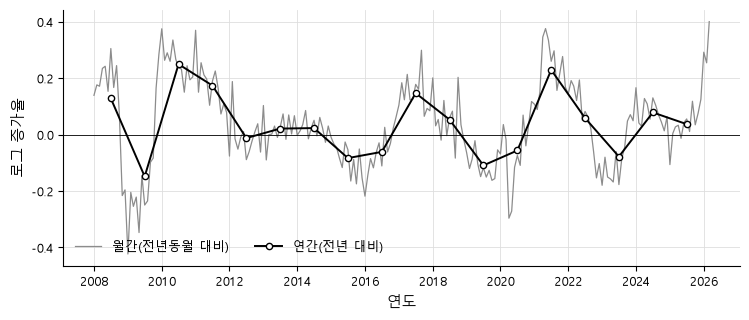

In [10]:
# 그림 1(논문 그림 1). 총수출 증가율: 월간 vs 연간
gm=res[('g','M')]; ga=res[('g','A')]
f=plt.figure(figsize=(7.6,3.3)); ax=f.gca()
ax.plot(pd.to_datetime(gm['p'].astype(int).astype(str),format='%Y%m'),gm['g'],lw=0.9,color=MGRAY,label='월간(전년동월 대비)')
ax.plot(pd.to_datetime(ga['p'].astype(int).astype(str)+'07',format='%Y%m'),ga['g'],
        lw=1.4,color='black',marker='o',ms=4.5,mfc='white',mec='black',mew=1.0,label='연간(전년 대비)')
ax.axhline(0,color='black',lw=0.6)
ax.set_ylabel('로그 증가율'); ax.set_xlabel('연도')
ax.legend(loc='lower left', ncol=2); save_show(f,'fm_growth.png')

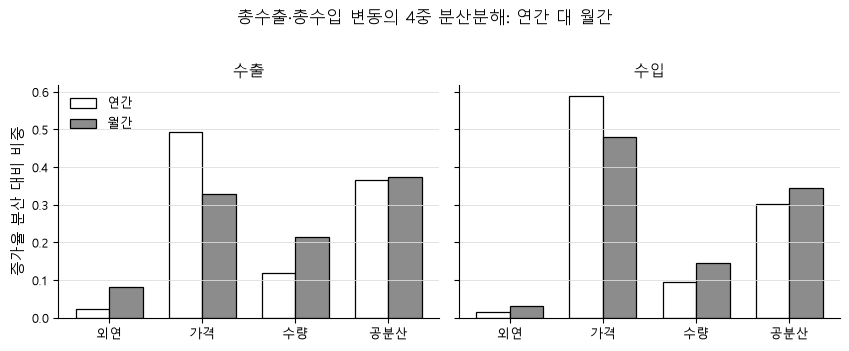

In [11]:
# [논문 제외] 4중 분산분해: 연간 vs 월간 — 표 2와 중복이라 논문에서 뺐고, 참고용으로만 생성
cats=['외연','가격','수량','공분산']; keys=['ext','price','qty','cov']
f,axs=plt.subplots(1,2,figsize=(8.6,3.4),sharey=True)
for ax,flow in [(axs[0],'수출'),(axs[1],'수입')]:
    A=[res[(flow,'연간')][2][k] for k in keys]; M=[res[(flow,'월간')][2][k] for k in keys]
    x=np.arange(4); w=0.36
    ax.bar(x-w/2,A,w,facecolor='white',edgecolor='black',lw=0.9,label='연간')
    ax.bar(x+w/2,M,w,facecolor=MGRAY,edgecolor='black',lw=0.9,label='월간')
    ax.set_xticks(x); ax.set_xticklabels(cats); ax.set_title(flow)
    ax.axhline(0,color='black',lw=0.6); ax.grid(axis='x')
axs[0].set_ylabel('증가율 분산 대비 비중'); axs[0].legend(loc='upper left')
f.suptitle('총수출·총수입 변동의 4중 분산분해: 연간 대 월간', y=1.02)
save_show(f,'fm_fourway.png')

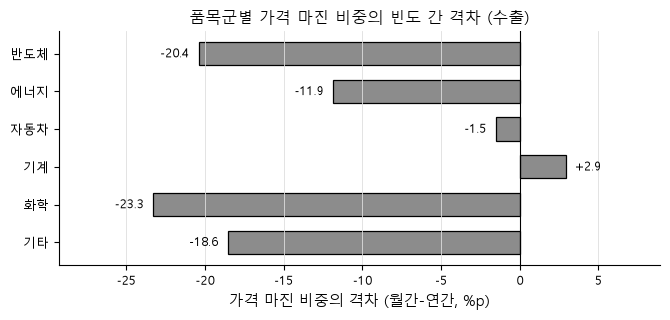

In [12]:
# [논문 제외] 품목군별 가격 격차 — 표 4와 중복이라 논문에서 뺐고, 참고용으로만 생성
gx=g3.iloc[:6]  # 마지막 행(에너지 수입) 제외
short={'반도체(8541·42)':'반도체','에너지(27)':'에너지','자동차(87)':'자동차',
       '기계(84)':'기계','화학(28·29·39)':'화학','기타':'기타'}
lab=[short.get(k,k) for k in gx['품목군']][::-1]
val=(gx['가격격차']*100).tolist()[::-1]
f=plt.figure(figsize=(6.8,3.3)); ax=f.gca()
ax.barh(lab,val,facecolor=MGRAY,edgecolor='black',lw=0.9,height=0.62)
for i,v in enumerate(val):
    ax.text(v-0.6 if v<0 else v+0.6, i, f'{v:+.1f}', va='center', ha='right' if v<0 else 'left', fontsize=9)
ax.axvline(0,color='black',lw=0.8)
ax.set_xlabel('가격 마진 비중의 격차 (월간-연간, %p)')
ax.set_title('품목군별 가격 마진 비중의 빈도 간 격차 (수출)')
ax.grid(axis='y'); ax.set_xlim(min(val)-6, max(val)+6)
save_show(f,'fm_gap_groups.png')

단가 전년 대비 변화의 표준편차: 월간 0.521 연간 0.445


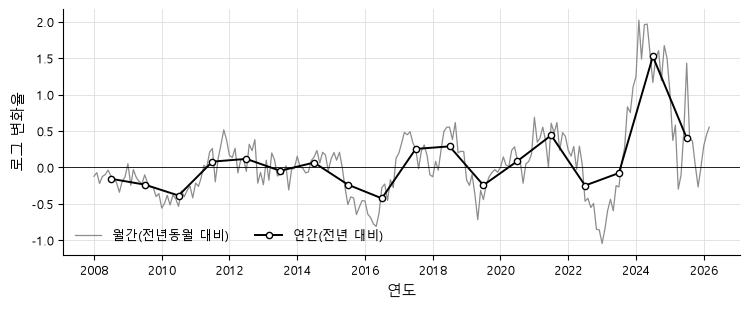

In [13]:
# 그림 2(논문 그림 2). 반도체 집계 단가의 전년 대비 변화: 월간 vs 연간
uvM=q("SELECT yyyymm p, SUM(v)/SUM(w) uv FROM mx WHERE SUBSTR(hs6,1,4) IN ('8541','8542') AND w>0 GROUP BY 1 ORDER BY 1")
uvM['d']=np.log(uvM['uv']/uvM['uv'].shift(12))
uvA=q("SELECT yr p, SUM(v)/SUM(w) uv FROM ax WHERE SUBSTR(hs6,1,4) IN ('8541','8542') AND w>0 GROUP BY 1 ORDER BY 1")
uvA['d']=np.log(uvA['uv']/uvA['uv'].shift(1))
print('단가 전년 대비 변화의 표준편차: 월간', round(uvM['d'].std(ddof=1),3), '연간', round(uvA['d'].std(ddof=1),3))
f=plt.figure(figsize=(7.6,3.2)); ax=f.gca()
ax.plot(pd.to_datetime(uvM['p'].astype(int).astype(str),format='%Y%m'),uvM['d'],lw=0.9,color=MGRAY,label='월간(전년동월 대비)')
ax.plot(pd.to_datetime(uvA['p'].astype(int).astype(str)+'07',format='%Y%m'),uvA['d'],
        lw=1.4,color='black',marker='o',ms=4.5,mfc='white',mec='black',mew=1.0,label='연간(전년 대비)')
ax.axhline(0,color='black',lw=0.6)
ax.set_ylabel('로그 변화율'); ax.set_xlabel('연도')
ax.legend(loc='lower left', ncol=2); save_show(f,'fm_semi_uv.png')

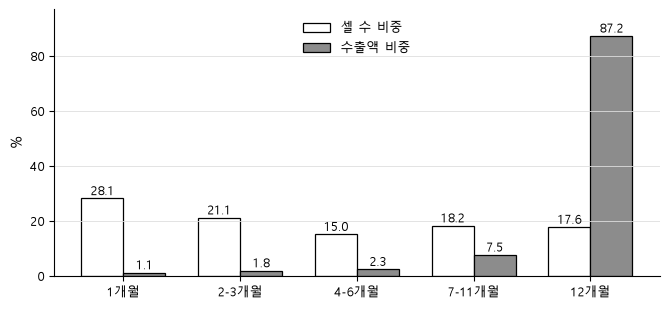

In [14]:
# 그림 3(논문 그림 3). 연간 '활성' 셀의 연중 실거래 개월수 분포
dm=q('''WITH cy AS (SELECT yyyymm//100 yr, stat_cd, hs6, COUNT(*) m, SUM(v) v FROM mx WHERE yyyymm//100<=2025 GROUP BY 1,2,3)
SELECT CASE WHEN m=1 THEN 1 WHEN m<=3 THEN 2 WHEN m<=6 THEN 3 WHEN m<=11 THEN 4 ELSE 5 END b,
       COUNT(*) cells, SUM(v) val FROM cy GROUP BY 1 ORDER BY 1''')
cs=dm['cells']/dm['cells'].sum()*100; vs=dm['val']/dm['val'].sum()*100
xl=['1개월','2-3개월','4-6개월','7-11개월','12개월']
f=plt.figure(figsize=(6.8,3.2)); ax=f.gca()
x=np.arange(5); w=0.36
b1=ax.bar(x-w/2,cs,w,facecolor='white',edgecolor='black',lw=0.9,label='셀 수 비중')
b2=ax.bar(x+w/2,vs,w,facecolor=MGRAY,edgecolor='black',lw=0.9,label='수출액 비중')
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1.2, f'{b.get_height():.1f}', ha='center', fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels(xl); ax.set_ylabel('%'); ax.set_ylim(0,100)
ax.legend(loc='upper center'); ax.grid(axis='x')
save_show(f,'fm_months.png')

## 판정 요약

- **(a) 순위 역전 없음**: 가격 > 수량 > 외연 (수출·수입, 두 빈도 공통)
- **(b) 크기 격차**: 수출 가격 49.2→32.9%, 수량 12.0→21.5%, 외연 2.2→8.2%
- **핵심**: 월간이 추가로 여는 분산(+66%)의 92%는 수량·외연·공분산 — 가격의 절대 기여는 빈도 불변. 사전 예상(연간이 가격 과소평가) 기각
- **(c) 위치**: 가격격차 최대는 화학(−23.3pp)·반도체(−20.4pp); 자동차·기계 ≈0
- **회전의 실체**: 연간 활성 셀의 28%가 연중 1개월 거래(금액 1.1%), 진입의 93.6%가 재진입, 퇴출의 82.9%가 12개월 내 복귀

In [15]:
con.close(); print('done')

done
